In [1]:
import xarray as xr
import os
import glob
import numpy as np
import warnings
import matplotlib.pyplot as plt
import sys
import cmocean

warnings.filterwarnings("ignore")
sys.path.append('../src')
from plot_helpers import create_animation_ffmpeg, default_rcParams

%load_ext autoreload
%autoreload 3

In [2]:
def read_skill(exp='subfilter/FGR3/EXP1', factors=[4,9,12,15], base_path='/scratch/pp2681/mom6/CM26_ML_models/ocean3d/'):
    ds = {}
    for factor in factors:
        data = xr.open_dataset(f'{base_path}/{exp}/skill-test/factor-{factor}.nc', chunks={'zl':1})
        data['zl'] = -data['zl']
        try:
            data['Tdd_pred'] = (data['Txx_pred'] - data['Tyy_pred']) * 0.5
            data['Ttr_pred'] = (data['Txx_pred'] + data['Tyy_pred']) * 0.5
            data['Tdd'] = (data['Txx'] - data['Tyy']) * 0.5
            data['Ttr'] = (data['Txx'] + data['Tyy']) * 0.5
        except:
            pass
        ds[factor] = data
        ds['stats'] = xr.open_dataset(f'{base_path}/{exp}/model/logger.nc')
        
    return ds

In [3]:
dd ={}
for lr in [0.05]:
    for exp in ['N8-forcing-fluxes']:
        try:
            dd[f'{exp}-{lr}'] = read_skill(f'subfilter/FGR3/equivariant/learning_rate/{exp}/{lr}')
        except:
            pass

dd['exp1'] = read_skill(f'subfilter/FGR3/EXP1')

In [8]:
import cmocean
import matplotlib.patches as patches
def plot_metric(exp=None, metric='R2_away',vmin=-1,vmax=1,cmap=cmocean.cm.balance,err_format="%.2f", show_numbers=True, title=False, xlabel=False, ylabel=False, add_yellow_rectangle=True, add_orange_rectangle=True, add_cyan_rectangle=True):
    data = xr.concat([exp[factor][metric] for factor in [4,9,12,15]], dim='factor')
    im = data.drop_vars(['zl']).plot(x='factor', y='zl',cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)

    if show_numbers:
    # Add text annotations
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                plt.text(i, j, err_format % float(data[i,j]),
                        ha='center', va='center', color='white', fontsize=10)

    if add_yellow_rectangle:
        rectangle = patches.Rectangle(
                                        (1 - 0.45, 0 - 0.45),  # Lower-left corner of the rectangle
                                        0.9,  # Width (1 cell)
                                        0.9,  # Height (1 cell)
                                        linewidth=2,  # Border thickness
                                        edgecolor='y',  # Border color
                                        facecolor='none',  # No fill color
                                    )
        plt.gca().add_patch(rectangle)
    if add_orange_rectangle:
        rectangle = patches.Rectangle(
                                        (0 - 0.45, 0 - 0.45),  # Lower-left corner of the rectangle
                                        0.9,  # Width (1 cell)
                                        0.9,  # Height (1 cell)
                                        linewidth=2,  # Border thickness
                                        edgecolor='tab:orange',  # Border color
                                        facecolor='none',  # No fill color
                                    )
        plt.gca().add_patch(rectangle)

    if add_cyan_rectangle:
        rectangle = patches.Rectangle(
                                        (1 - 0.45, 7 - 0.45),  # Lower-left corner of the rectangle
                                        0.9,  # Width (1 cell)
                                        0.9,  # Height (1 cell)
                                        linewidth=2,  # Border thickness
                                        edgecolor='c',  # Border color
                                        facecolor='none',  # No fill color
                                    )
        plt.gca().add_patch(rectangle)
        
    
    if ylabel:
        plt.yticks(np.arange(10),[5, 55, 110, 180,330, 730,1500,2500,3500,4500]);
        plt.ylabel('Depth [m]')
    else:
        plt.yticks(np.arange(10),['']*10);
        plt.ylabel('')
    
    if xlabel:
        plt.xticks(np.arange(4),['$0.4^\circ$','$0.9^\circ$','$1.2^\circ$','$1.5^\circ$']);
        plt.xlabel('Coarse-grid spacing, $\Delta$')
    else:
        plt.xticks(np.arange(4), ['']*4)
        plt.xlabel('')
        
    if metric == 'R2':
        title_str = '$R^2$'
    elif metric == 'corr':
        title_str = 'Correlation'
    elif metric == 'opt_scaling':
        title_str = 'Optimal scaling'
    
    mean_val = float(data.mean())
    min_val = float(data.min())
    max_val = float(data.max())
    
    if title:
        plt.title(metric+f' = ${err_format}$ $({err_format}-{err_format})$' % (mean_val,min_val,max_val), fontsize=12)
    else:
        plt.title('')
    
    plt.gca().invert_yaxis()
    return im

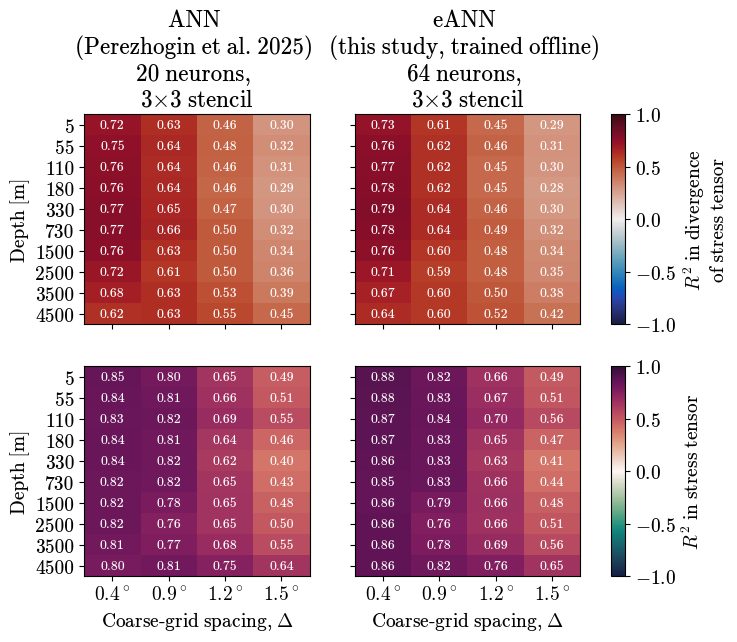

In [36]:
default_rcParams({'figure.subplot.wspace': 0.2, 'figure.subplot.hspace': 0.2, 'font.size':14})
fig = plt.figure(figsize=(8,6))

plt.subplot(2,2,1)
im_R2=plot_metric(dd['exp1'], 'R2_away', ylabel=True, xlabel=False, add_cyan_rectangle=False, add_yellow_rectangle=False, add_orange_rectangle=False);
plt.title('ANN \n(Perezhogin et al. 2025) \n20 neurons, \n3$\\times$3 stencil')
plt.subplot(2,2,2)
im_R2=plot_metric(dd['N8-forcing-fluxes-0.05'], 'R2_away', ylabel=False, xlabel=False, add_cyan_rectangle=False, add_yellow_rectangle=False, add_orange_rectangle=False);
plt.title('eANN \n(this study, trained offline) \n64 neurons, \n3$\\times$3 stencil')

plt.subplot(2,2,3)
im_R2T=plot_metric(dd['exp1'], 'R2T_away', ylabel=True, xlabel=True, add_cyan_rectangle=False, add_yellow_rectangle=False, add_orange_rectangle=False, cmap=cmocean.cm.curl);
plt.title('')
plt.subplot(2,2,4)
im_R2T=plot_metric(dd['N8-forcing-fluxes-0.05'], 'R2T_away', ylabel=False, xlabel=True, add_cyan_rectangle=False, add_yellow_rectangle=False, add_orange_rectangle=False, cmap=cmocean.cm.curl);
plt.title('')

axes = plt.gcf().axes
plt.colorbar(im_R2, ax=axes[0:2], 
             label='$R^2$ in divergence \nof stress tensor', aspect=15)

plt.colorbar(im_R2T, ax=axes[2:4], 
             label='$R^2$ in stress tensor', aspect=15)

plt.savefig('paper_figures/R2_skill.pdf', bbox_inches='tight')